Hoàng Ngọc Dung - 23139006

In [1054]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [1055]:
df = pd.read_csv("clean_feature.csv")
df["datetime"] = pd.to_datetime(df["Day"]) + pd.to_timedelta(df["hour"], unit="h")
print(pd.Series(df["ServiceID"].unique()).sort_values().to_list())

print(df["ServiceID"].unique().shape)  
df

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
(12,)


,Day,DoWeek,hour,count,passed,period,data,ServiceID,datetime
0,2021-12-29,2,17,2974,2974,63.952589,612.081036,2,2021-12-29 17:00:00
1,2021-12-29,2,17,4528,4528,63.000000,960.307862,11,2021-12-29 17:00:00
2,2021-12-29,2,17,19,19,62.000000,566.315789,5,2021-12-29 17:00:00
3,2021-12-29,2,17,1207,1207,63.000000,601.025684,7,2021-12-29 17:00:00
4,2021-12-29,2,18,8450,8450,63.942130,611.024024,2,2021-12-29 18:00:00
...,...,...,...,...,...,...,...,...,...
450666,2023-07-24,0,18,1,1,62.000000,624.000000,1,2023-07-24 18:00:00
450667,2023-07-24,0,18,108,108,62.000000,1075.972222,5,2023-07-24 18:00:00
450668,2023-07-24,0,18,5279,5279,63.000000,599.900170,7,2023-07-24 18:00:00
450669,2023-07-24,0,18,2,2,63.000000,1437.500000,0,2023-07-24 18:00:00


In [1056]:
# a = df[(df["datetime"].dt.year == 2023) & (df["datetime"].dt.month == 6)]
# a
# df = df.set_index("datetime")
# df = df.sort_index()
# # query theo tháng/năm
# a = df.loc["2023-05":"2023-06"]
# print(a.shape)
# print(a.head())


In [1057]:
def query(df, t_datetime, months=0, years=0, days=0, hours=0):
    t = pd.to_datetime(t_datetime)
    
    offset = pd.DateOffset(years=years, months=months)
    td = pd.Timedelta(days=days, hours=hours)
    start = t - offset - td
    
    #[t - delta_t, t]
    mask = (df["datetime"] >= start) & (df["datetime"] <= t)
    return df.loc[mask]

In [1058]:
t = "2023-07-24 18:00:00"
result = query(df, t, years=0, months=4, days=0, hours=0)
result = result.sort_index()
result

,Day,DoWeek,hour,count,passed,period,data,ServiceID,datetime
81047,2023-03-24,4,18,13704,13704,63.95359,634.817353,2,2023-03-24 18:00:00
81048,2023-03-24,4,18,17758,17758,63.00000,931.950670,11,2023-03-24 18:00:00
81049,2023-03-24,4,18,235,235,62.00000,1047.114894,5,2023-03-24 18:00:00
81050,2023-03-24,4,18,7546,7546,63.00000,600.296846,7,2023-03-24 18:00:00
81051,2023-03-24,4,18,2,2,62.00000,318.000000,8,2023-03-24 18:00:00
...,...,...,...,...,...,...,...,...,...
450666,2023-07-24,0,18,1,1,62.00000,624.000000,1,2023-07-24 18:00:00
450667,2023-07-24,0,18,108,108,62.00000,1075.972222,5,2023-07-24 18:00:00
450668,2023-07-24,0,18,5279,5279,63.00000,599.900170,7,2023-07-24 18:00:00
450669,2023-07-24,0,18,2,2,63.00000,1437.500000,0,2023-07-24 18:00:00


In [1059]:
a = result.groupby("ServiceID")["count"].mean()
a

ServiceID
0        2.395362
1       45.397623
2     6385.617198
3        1.057471
4        1.611187
5       93.118155
6        1.574595
7     3264.524239
8        3.875595
9        3.489565
10      19.074913
11    8556.697000
Name: count, dtype: float64

In [1060]:
# Rút trích đặc trưng trong khoảng [t - delta_t, t]
features = (
    result.groupby(["datetime", "ServiceID"])
        .agg(
        mean_count=("count", "mean"),
        mean_pass =("passed", "mean"),
        mean_data =("data", "mean"),
        time      =("period", "count")  
        )
)

matrix = (
    features.unstack(level="ServiceID", fill_value=0)
            .sort_index(axis=1, level=1)   
)

matrix["DoW"] = matrix.index.dayofweek
matrix["HiD"] = matrix.index.hour

matrix


,mean_count,mean_data,mean_pass,time,mean_count,mean_data,mean_pass,time,mean_count,mean_data,...,mean_count,mean_data,mean_pass,time,mean_count,mean_data,mean_pass,time,DoW,HiD
ServiceID,0,0,0,0,1,1,1,1,2,2,...,10,10,10,10,11,11,11,11,,
datetime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 18:00:00,0.000000,0.000000,0.000000,0,0.000,0.000000,0.000,0,11248.400000,632.645271,...,0.000000,0.000000,0.000000,0,14534.800000,937.844573,14534.800000,5,4,18
2023-03-24 19:00:00,1.000000,836.000000,1.000000,1,0.000,0.000000,0.000,0,8014.571429,627.616130,...,0.000000,0.000000,0.000000,0,9923.428571,913.733160,9923.428571,7,4,19
2023-03-24 20:00:00,1.000000,877.000000,1.000000,2,0.000,0.000000,0.000,0,5948.375000,622.320818,...,0.000000,0.000000,0.000000,0,7432.125000,923.108912,7432.125000,8,4,20
2023-03-24 21:00:00,0.000000,0.000000,0.000000,0,0.000,0.000000,0.000,0,9442.000000,614.907664,...,0.000000,0.000000,0.000000,0,12304.000000,908.078407,12304.000000,4,4,21
2023-03-24 22:00:00,1.000000,945.000000,1.000000,1,0.000,0.000000,0.000,0,3323.750000,604.097474,...,0.000000,0.000000,0.000000,0,4328.625000,925.008268,4328.625000,8,4,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-24 14:00:00,6.250000,1604.770833,6.250000,4,87.625,561.074241,87.625,8,8992.750000,660.691365,...,15.000000,378251.423480,15.000000,8,11757.250000,945.996360,11757.250000,8,0,14
2023-07-24 15:00:00,3.125000,1706.733333,3.125000,8,83.500,559.099741,83.500,8,9461.000000,652.613439,...,15.000000,378251.791223,15.000000,8,12506.500000,951.279353,12506.500000,8,0,15


In [1061]:
# tổng theo cột (dọc theo hàng) → axis=0
# tổng theo hàng (ngang theo cột) → axis=1
matrix["label"] = (matrix["mean_count"] == matrix["mean_pass"]).all(axis=1).astype(int)
print(matrix[("label")].value_counts())

matrix

label
1    1990
0     939
Name: count, dtype: int64


mean_count    mean_data mean_pass time mean_count  \
ServiceID                    0            0         0    0          1   
datetime                                                                
2023-03-24 18:00:00   0.000000     0.000000  0.000000    0      0.000   
2023-03-24 19:00:00   1.000000   836.000000  1.000000    1      0.000   
2023-03-24 20:00:00   1.000000   877.000000  1.000000    2      0.000   
2023-03-24 21:00:00   0.000000     0.000000  0.000000    0      0.000   
2023-03-24 22:00:00   1.000000   945.000000  1.000000    1      0.000   
...                        ...          ...       ...  ...        ...   
2023-07-24 14:00:00   6.250000  1604.770833  6.250000    4     87.625   
2023-07-24 15:00:00   3.125000  1706.733333  3.125000    8     83.500   
2023-07-24 16:00:00   2.571429  1408.761905  2.571429    7     62.625   
2023-07-24 17:00:00   1.000000  2202.000000  1.000000    1      8.500   
2023-07-24 18:00:00   1.333333  1583.500000  1.333333    3      2.625   

                      mean_data mean_pass time    mean_count   mean_data  ...  \
ServiceID                     1         1    1             2           2  ...   
datetime                                                                  ...   
2023-03-24 18:00:00    0.000000     0.000    0  11248.400000  632.645271  ...   
2023-03-24 19:00:00    0.000000     0.000    0   8014.571429  627.616130  ...   
2023-03-24 20:00:00    0.000000     0.000    0   5948.375000  622.320818  ...   
2023-03-24 21:00:00    0.000000     0.000    0   9442.000000  614.907664  ...   
2023-03-24 22:00:00    0.000000     0.000    0   3323.750000  604.097474  ...   
...                         ...       ...  ...           ...         ...  ...   
2023-07-24 14:00:00  561.074241    87.625    8   8992.750000  660.691365  ...   
2023-07-24 15:00:00  559.099741    83.500    8   9461.000000  652.613439  ...   
2023-07-24 16:00:00  587.271777    62.625    8   9103.000000  640.012532  ...   
2023-07-24 17:00:00  605.101780     8.500    8   8451.250000  641.604435  ...   
2023-07-24 18:00:00  625.552083     2.625    8   9979.800000  634.672423  ...   

                                    mean_pass time    mean_count   mean_data  \
ServiceID                       10         10   10            11          11   
datetime                                                                       
2023-03-24 18:00:00       0.000000   0.000000    0  14534.800000  937.844573   
2023-03-24 19:00:00       0.000000   0.000000    0   9923.428571  913.733160   
2023-03-24 20:00:00       0.000000   0.000000    0   7432.125000  923.108912   
2023-03-24 21:00:00       0.000000   0.000000    0  12304.000000  908.078407   
2023-03-24 22:00:00       0.000000   0.000000    0   4328.625000  925.008268   
...                            ...        ...  ...           ...         ...   
2023-07-24 14:00:00  378251.423480  15.000000    8  11757.250000  945.996360   
2023-07-24 15:00:00  378251.791223  15.000000    8  12506.500000  951.279353   
2023-07-24 16:00:00  378251.514512  15.000000    8  11957.750000  943.866314   
2023-07-24 17:00:00  378251.973496  15.416667   12  10919.833333  930.734457   
2023-07-24 18:00:00  378251.912747  19.200000   10  12427.200000  916.993728   

                        mean_pass time DoW HiD label  
ServiceID                      11   11                
datetime                                              
2023-03-24 18:00:00  14534.800000    5   4  18     0  
2023-03-24 19:00:00   9923.428571    7   4  19     0  
2023-03-24 20:00:00   7432.125000    8   4  20     1  
2023-03-24 21:00:00  12304.000000    4   4  21     0  
2023-03-24 22:00:00   4328.625000    8   4  22     1  
...                           ...  ...  ..  ..   ...  
2023-07-24 14:00:00  11757.250000    8   0  14     1  
2023-07-24 15:00:00  12506.500000    8   0  15     0  
2023-07-24 16:00:00  11957.750000    8   0  16     1  
2023-07-24 17:00:00  10919.833333   12   0  17     0  
2023-07-24 18:00:00  12427

In [1062]:
def future_label(df, hours):
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["error"] = (df["count"] != df["passed"]).astype(int)
    err_by_t = df.groupby("datetime")["error"].max().sort_index()

    future_label = (
        (err_by_t.shift(-1).fillna(0).astype(int)) |
        (err_by_t.shift(-2).fillna(0).astype(int))
    ).astype(int)

    return future_label.rename("label")


In [1063]:
matrix["future"] =  future_label(result, 2)
matrix.drop_duplicates()
matrix

,mean_count,mean_data,mean_pass,time,mean_count,mean_data,mean_pass,time,mean_count,mean_data,...,mean_pass,time,mean_count,mean_data,mean_pass,time,DoW,HiD,label,future
ServiceID,0,0,0,0,1,1,1,1,2,2,...,10,10,11,11,11,11,,,,
datetime,,,,,,,,,,,,,,,,,,,,,
2023-03-24 18:00:00,0.000000,0.000000,0.000000,0,0.000,0.000000,0.000,0,11248.400000,632.645271,...,0.000000,0,14534.800000,937.844573,14534.800000,5,4,18,0,1
2023-03-24 19:00:00,1.000000,836.000000,1.000000,1,0.000,0.000000,0.000,0,8014.571429,627.616130,...,0.000000,0,9923.428571,913.733160,9923.428571,7,4,19,0,1
2023-03-24 20:00:00,1.000000,877.000000,1.000000,2,0.000,0.000000,0.000,0,5948.375000,622.320818,...,0.000000,0,7432.125000,923.108912,7432.125000,8,4,20,1,1
2023-03-24 21:00:00,0.000000,0.000000,0.000000,0,0.000,0.000000,0.000,0,9442.000000,614.907664,...,0.000000,0,12304.000000,908.078407,12304.000000,4,4,21,0,0
2023-03-24 22:00:00,1.000000,945.000000,1.000000,1,0.000,0.000000,0.000,0,3323.750000,604.097474,...,0.000000,0,4328.625000,925.008268,4328.625000,8,4,22,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-24 14:00:00,6.250000,1604.770833,6.250000,4,87.625,561.074241,87.625,8,8992.750000,660.691365,...,15.000000,8,11757.250000,945.996360,11757.250000,8,0,14,1,1
2023-07-24 15:00:00,3.125000,1706.733333,3.125000,8,83.500,559.099741,83.500,8,9461.000000,652.613439,...,15.000000,8,12506.500000,951.279353,12506.500000,8,0,15,0,1


In [1064]:
start_time = matrix.index.get_level_values("datetime").min()
end_time   = matrix.index.get_level_values("datetime").max()
print(start_time)
print(end_time)

2023-03-24 18:00:00
2023-07-24 18:00:00


In [1065]:
matrix.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[1] != "" else str(col[0])
    for col in matrix.columns.to_flat_index()
]

print(matrix.shape)
print(matrix.columns[:10])



(2929, 52)
Index(['mean_count_0', 'mean_data_0', 'mean_pass_0', 'time_0', 'mean_count_1',
       'mean_data_1', 'mean_pass_1', 'time_1', 'mean_count_2', 'mean_data_2'],
      dtype='object')


In [1066]:
datetimes = matrix.index.get_level_values("datetime")
split_time = end_time - pd.DateOffset(months=3)
train_val = matrix[datetimes <= split_time]
test      = matrix[datetimes >  split_time]

X = train_val.drop(columns=["label", "future"])   
y = train_val["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    shuffle=True,
    random_state=42
)

X_test = test.drop(columns=["label", "future"])
y_test = test["label"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (521, 50) (521,)
Val:   (224, 50) (224,)
Test:  (2184, 50) (2184,)


In [1067]:
class HourToXY(BaseEstimator, TransformerMixin):
    def __init__(self, period=24):
        self.period = period
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = np.asarray(X)
        h = X if X.ndim == 1 else X[:, 0]
        theta = 2*np.pi*h/self.period
        return np.c_[np.cos(theta), np.sin(theta)]
    def get_feature_names_out(self, input_features=None):
        base = input_features[0] if input_features else "hour"
        return np.array([f"{base}_x", f"{base}_y"])

In [1068]:
hour_to_xy = HourToXY(period=24)
count = [col for col in matrix.columns if "mean_count" in col]
passed = [col for col in matrix.columns if "mean_pass" in col]
data = [col for col in matrix.columns if "mean_data" in col]
time = [col for col in matrix.columns if "time" in col]
hour = [col for col in matrix.columns if "HiD" in col]
DoW = [col for col in matrix.columns if "DoW" in col]

print("Count & passed cols:", count + passed)
print("Data cols:", data)
print("Time cols:", time)
print("Hour cols:", hour)
print("DoW cols:", DoW)

# ct = ColumnTransformer(
#         transformers=[
#                 ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False), count+passed),
#                 ("time", MinMaxScaler(), time),
#                 ("data", StandardScaler(), data),
#                 ("DoW", "passthrough", DoW),  # giữ nguyên
#                 ("HiD", hour_to_xy, hour),
#         ]
# )
ct = ColumnTransformer(
        transformers=[
                ("onehot", StandardScaler(), count+passed),
                ("time", MinMaxScaler(), time),
                ("data", StandardScaler(), data),
                ("DoW", "passthrough", DoW),  # giữ nguyên
                ("HiD", hour_to_xy, hour),
        ]
)
ct

Count & passed cols: ['mean_count_0', 'mean_count_1', 'mean_count_2', 'mean_count_3', 'mean_count_4', 'mean_count_5', 'mean_count_6', 'mean_count_7', 'mean_count_8', 'mean_count_9', 'mean_count_10', 'mean_count_11', 'mean_pass_0', 'mean_pass_1', 'mean_pass_2', 'mean_pass_3', 'mean_pass_4', 'mean_pass_5', 'mean_pass_6', 'mean_pass_7', 'mean_pass_8', 'mean_pass_9', 'mean_pass_10', 'mean_pass_11']
Data cols: ['mean_data_0', 'mean_data_1', 'mean_data_2', 'mean_data_3', 'mean_data_4', 'mean_data_5', 'mean_data_6', 'mean_data_7', 'mean_data_8', 'mean_data_9', 'mean_data_10', 'mean_data_11']
Time cols: ['time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6', 'time_7', 'time_8', 'time_9', 'time_10', 'time_11']
Hour cols: ['HiD']
DoW cols: ['DoW']


,transformers,"[('onehot', ...), ('time', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [1069]:

X_num = X_train[count + passed + data + time]
n_num = X_num.shape[1]

pca = PCA().fit(X_num) 
explained = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(explained >= 0.95) + 1
print("95%:",n_components_95)


95%: 2


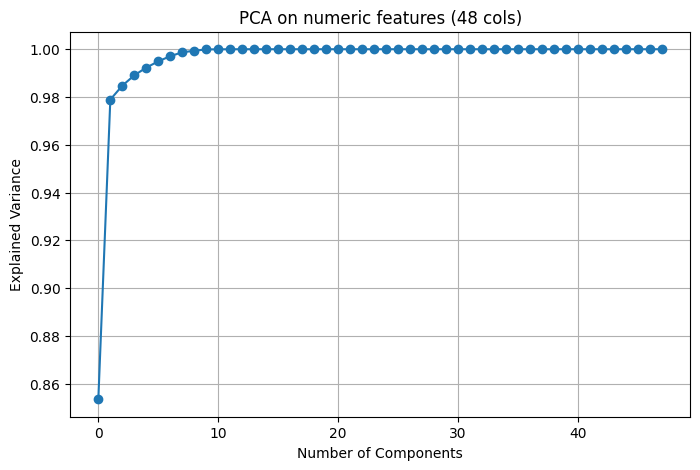

In [1070]:
plt.figure(figsize=(8,5))
plt.plot(explained, marker='o', label="Cumulative Explained Variance")

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")

plt.title("PCA on numeric features (48 cols)")
plt.grid(True)
plt.show()

In [1071]:
class PartialPCA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=2, n_num=48):
        self.n_components = n_components   
        self.n_num = n_num                 # số cột numeric cuối
        self.pca = PCA(n_components=n_components)

    def fit(self, X, y=None):
        X_num = X[:, -self.n_num:]
        self.pca.fit(X_num)
        return self

    def transform(self, X):
        X_num = X[:, -self.n_num:]
        X_rest = X[:, :-self.n_num]  # phần còn lại (HiD + DoW)
        X_num_pca = self.pca.transform(X_num)
        # HiD, DoW + PCA(48 cột) 
        return np.hstack([X_rest, X_num_pca])


In [1072]:
pipe = Pipeline([
    ("transform", ct),   
    ("partial_pca", PartialPCA()),
    ("svm", SVC(probability=True, class_weight="balanced"))
])
pipe

,steps,"[('transform', ...), ('partial_pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot', ...), ('time', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [1073]:
pipe.fit(X_train, y_train)

Xt_after_ct = pipe.named_steps["transform"].transform(X_train)

# lấy output sau PartialPCA
Xt_after_pca = pipe.named_steps["partial_pca"].transform(Xt_after_ct)

print("Shape sau PartialPCA:", Xt_after_pca.shape)
print("Một vài dòng:")
print(Xt_after_pca[:5])

Shape sau PartialPCA: (521, 5)
Một vài dòng:
[[-0.06149525 -0.179458    1.91634164  2.62265709  5.23492944]
 [-0.06149525 -0.45084392 -0.04066478 -0.61841341  2.96057766]
 [ 1.8141813   0.98334508  0.5469729   4.89153674 -3.28465165]
 [-0.64764417 -0.49729736 -1.46735152 -4.97015126  0.3582926 ]
 [ 0.91541962  0.92075517  0.6498525   5.3362778  -1.49954888]]


In [1074]:
pipe.fit(X_train, y_train)

y_val_pred = pipe.predict(X_val)
print("Val Accuracy:", accuracy_score(y_val, y_val_pred))

y_test_pred = pipe.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Val Accuracy: 0.7053571428571429
Test Accuracy: 0.6336996336996337


In [1075]:
param_grid = {
    'partial_pca__n_components': [10, 5, 8, 20],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", 
                    n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)



Fitting 3 folds for each of 36 candidates, totalling 108 fits


,estimator,Pipeline(step...ility=True))])
,param_grid,"{'partial_pca__n_components': [10, 5, ...], 'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.01, ...], 'svm__kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('onehot', ...), ('time', ...), ...]"


In [1076]:
print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_pipe = grid.best_estimator_
print("Test accuracy:", best_pipe.score(X_test, y_test))


Best params: {'partial_pca__n_components': 10, 'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV accuracy: 0.6814718844816513
Test accuracy: 0.6240842490842491


In [1077]:
from sklearn.metrics import accuracy_score

best_pipe = grid.best_estimator_
y_pred = best_pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Test score:", best_pipe.score(X_test, y_test))

Accuracy: 62.41%
Test score: 0.6240842490842491
